# Embedding Model Evaluation & Comparison (with BM25 Hybrid Retrieval)

This notebook evaluates and compares the performance of two embedding models in a RAG-like retrieval pipeline on insurance policy documents:
1. **Baseline Model**: `sentence-transformers/all-mpnet-base-v2`
2. **Custom Trained Model**: `D:/all-mpnet-base-v2-insurance-final` (local path)

## Retrieval Strategy
We use **Hybrid Search** with a weight distribution of:
- **75% Dense Score** (Cosine Similarity)
- **25% Sparse Score** (BM25 token-matching)

## Evaluation Metrics
- **Recall@1**: Proportion of queries where the true document chunk is ranked 1st.
- **Recall@5**: Proportion of queries where the true document chunk is in the top 5.
- **MRR (Mean Reciprocal Rank)**: Quality of ranking for the true document chunk.

### Step 1: Imports and Library Checks

In [1]:
import os
import json
import random
import re
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from langchain_text_splitters import RecursiveCharacterTextSplitter
from rank_bm25 import BM25Okapi

### Step 2: Define Paths and Configuration

In [2]:
POLICY_PATH = "C:/Users/Shaur/Downloads/insurance_policy.md"
DATASET_PATH = "C:/Users/Shaur/Downloads/insurance_retrieval_dataset_with_negatives.jsonl"
BASE_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
CUSTOM_MODEL_PATH = "D:/all-mpnet-base-v2-insurance-final/content/all-mpnet-base-v2-insurance-final"

### Step 3: Load Policy Document and Chunk with RecursiveCharacterTextSplitter

In [3]:
with open(POLICY_PATH, "r", encoding="utf-8") as f:
    policy_text = f.read()

splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
chunks = splitter.create_documents([policy_text])
chunk_texts = [doc.page_content for doc in chunks]
print(f"Total chunks created: {len(chunk_texts)}")

# Load JSONL Dataset
dataset = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            dataset.append(json.loads(line))
print(f"Total questions in dataset: {len(dataset)}")

Total chunks created: 340
Total questions in dataset: 102


### Step 4: Sample Queries and Map to Document Chunks (Ground Truth Resolver)
We sample 25 random queries and map each query's positive answer snippet to the most semantically overlapping chunk in our document corpus using Jaccard token similarity.

In [4]:
random.seed(42)
sampled_data = random.sample(dataset, 25)

def normalize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def get_jaccard(text1, text2):
    w1 = set(normalize(text1).split())
    w2 = set(normalize(text2).split())
    if not w1 or not w2:
        return 0.0
    return len(w1 & w2) / len(w1 | w2)

query_ground_truths = []
for item in sampled_data:
    query = item["query"]
    positive = item["positive"]
    
    best_idx = -1
    best_score = -1.0
    for idx, chunk in enumerate(chunk_texts):
        score = get_jaccard(chunk, positive)
        if score > best_score:
            best_score = score
            best_idx = idx
            
    query_ground_truths.append({
        "query": query,
        "positive": positive,
        "gt_chunk_idx": best_idx,
        "gt_score": best_score
    })
print("Ground truth matching complete.")

Ground truth matching complete.


### Step 5: Setup Sparse Retriever (BM25) and Hybrid Combiner

In [5]:
tokenized_corpus = [normalize(text).split() for text in chunk_texts]
bm25 = BM25Okapi(tokenized_corpus)

def compute_hybrid_scores(query, dense_scores, bm25_obj, weight_dense=0.75, weight_sparse=0.25):
    tokenized_query = normalize(query).split()
    bm25_scores = np.array(bm25_obj.get_scores(tokenized_query))
    
    min_bm25 = bm25_scores.min()
    max_bm25 = bm25_scores.max()
    if max_bm25 > min_bm25:
        norm_bm25 = (bm25_scores - min_bm25) / (max_bm25 - min_bm25)
    else:
        norm_bm25 = np.zeros_like(bm25_scores)
        
    return weight_dense * dense_scores + weight_sparse * norm_bm25

### Step 6: Setup Embedding Model Loader
Since the custom model's `SentenceTransformer` config files reference paths incompatible with the local environment package structure, we write a custom PyTorch loader using `transformers.AutoModel` to load the weights directly, compute mean pooling, and output L2 normalized embeddings.

In [6]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

class CustomEmbeddingsWrapper:
    def __init__(self, model_path_or_name):
        self.tokenizer = AutoTokenizer.from_pretrained(model_path_or_name)
        self.model = AutoModel.from_pretrained(model_path_or_name)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()
        
    def encode(self, texts, batch_size=32):
        if isinstance(texts, str):
            texts = [texts]
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            encoded_input = self.tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt', max_length=512)
            encoded_input = {k: v.to(self.device) for k, v in encoded_input.items()}
            
            with torch.no_grad():
                model_output = self.model(**encoded_input)
                
            embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
            embeddings = F.normalize(embeddings, p=2, dim=1)
            all_embeddings.append(embeddings.cpu())
        return torch.cat(all_embeddings, dim=0)

### Step 7: Define Evaluation Loop

In [7]:
def evaluate_model(model_wrapper):
    recalls_at_1 = []
    recalls_at_5 = []
    reciprocal_ranks = []
    
    corpus_embeddings = model_wrapper.encode(chunk_texts)
    
    for gt_data in query_ground_truths:
        query = gt_data["query"]
        gt_idx = gt_data["gt_chunk_idx"]
        
        query_embedding = model_wrapper.encode([query])
        dense_scores = torch.mm(query_embedding, corpus_embeddings.transpose(0, 1)).squeeze(0).numpy()
        combined_scores = compute_hybrid_scores(query, dense_scores, bm25)
        
        ranked_indices = np.argsort(combined_scores)[::-1]
        rank_idx = np.where(ranked_indices == gt_idx)[0][0]
        rank = rank_idx + 1
        
        recalls_at_1.append(1.0 if rank == 1 else 0.0)
        recalls_at_5.append(1.0 if rank <= 5 else 0.0)
        reciprocal_ranks.append(1.0 / rank)
        
    return np.mean(recalls_at_1), np.mean(recalls_at_5), np.mean(reciprocal_ranks)

### Step 8: Run Evaluation

In [8]:
print("Evaluating Baseline Model...")
baseline_wrapper = CustomEmbeddingsWrapper(BASE_MODEL_NAME)
base_r1, base_r5, base_mrr = evaluate_model(baseline_wrapper)
print(f"Baseline: Recall@1 = {base_r1:.4f}, Recall@5 = {base_r5:.4f}, MRR = {base_mrr:.4f}")

print("\nEvaluating Custom Trained Model...")
custom_wrapper = CustomEmbeddingsWrapper(CUSTOM_MODEL_PATH)
custom_r1, custom_r5, custom_mrr = evaluate_model(custom_wrapper)
print(f"Custom:   Recall@1 = {custom_r1:.4f}, Recall@5 = {custom_r5:.4f}, MRR = {custom_mrr:.4f}")

Evaluating Baseline Model...
Baseline: Recall@1 = 0.4000, Recall@5 = 0.7600, MRR = 0.5463

Evaluating Custom Trained Model...
Custom:   Recall@1 = 0.5600, Recall@5 = 0.7200, MRR = 0.6474


### Step 9: Plot Performance Comparison

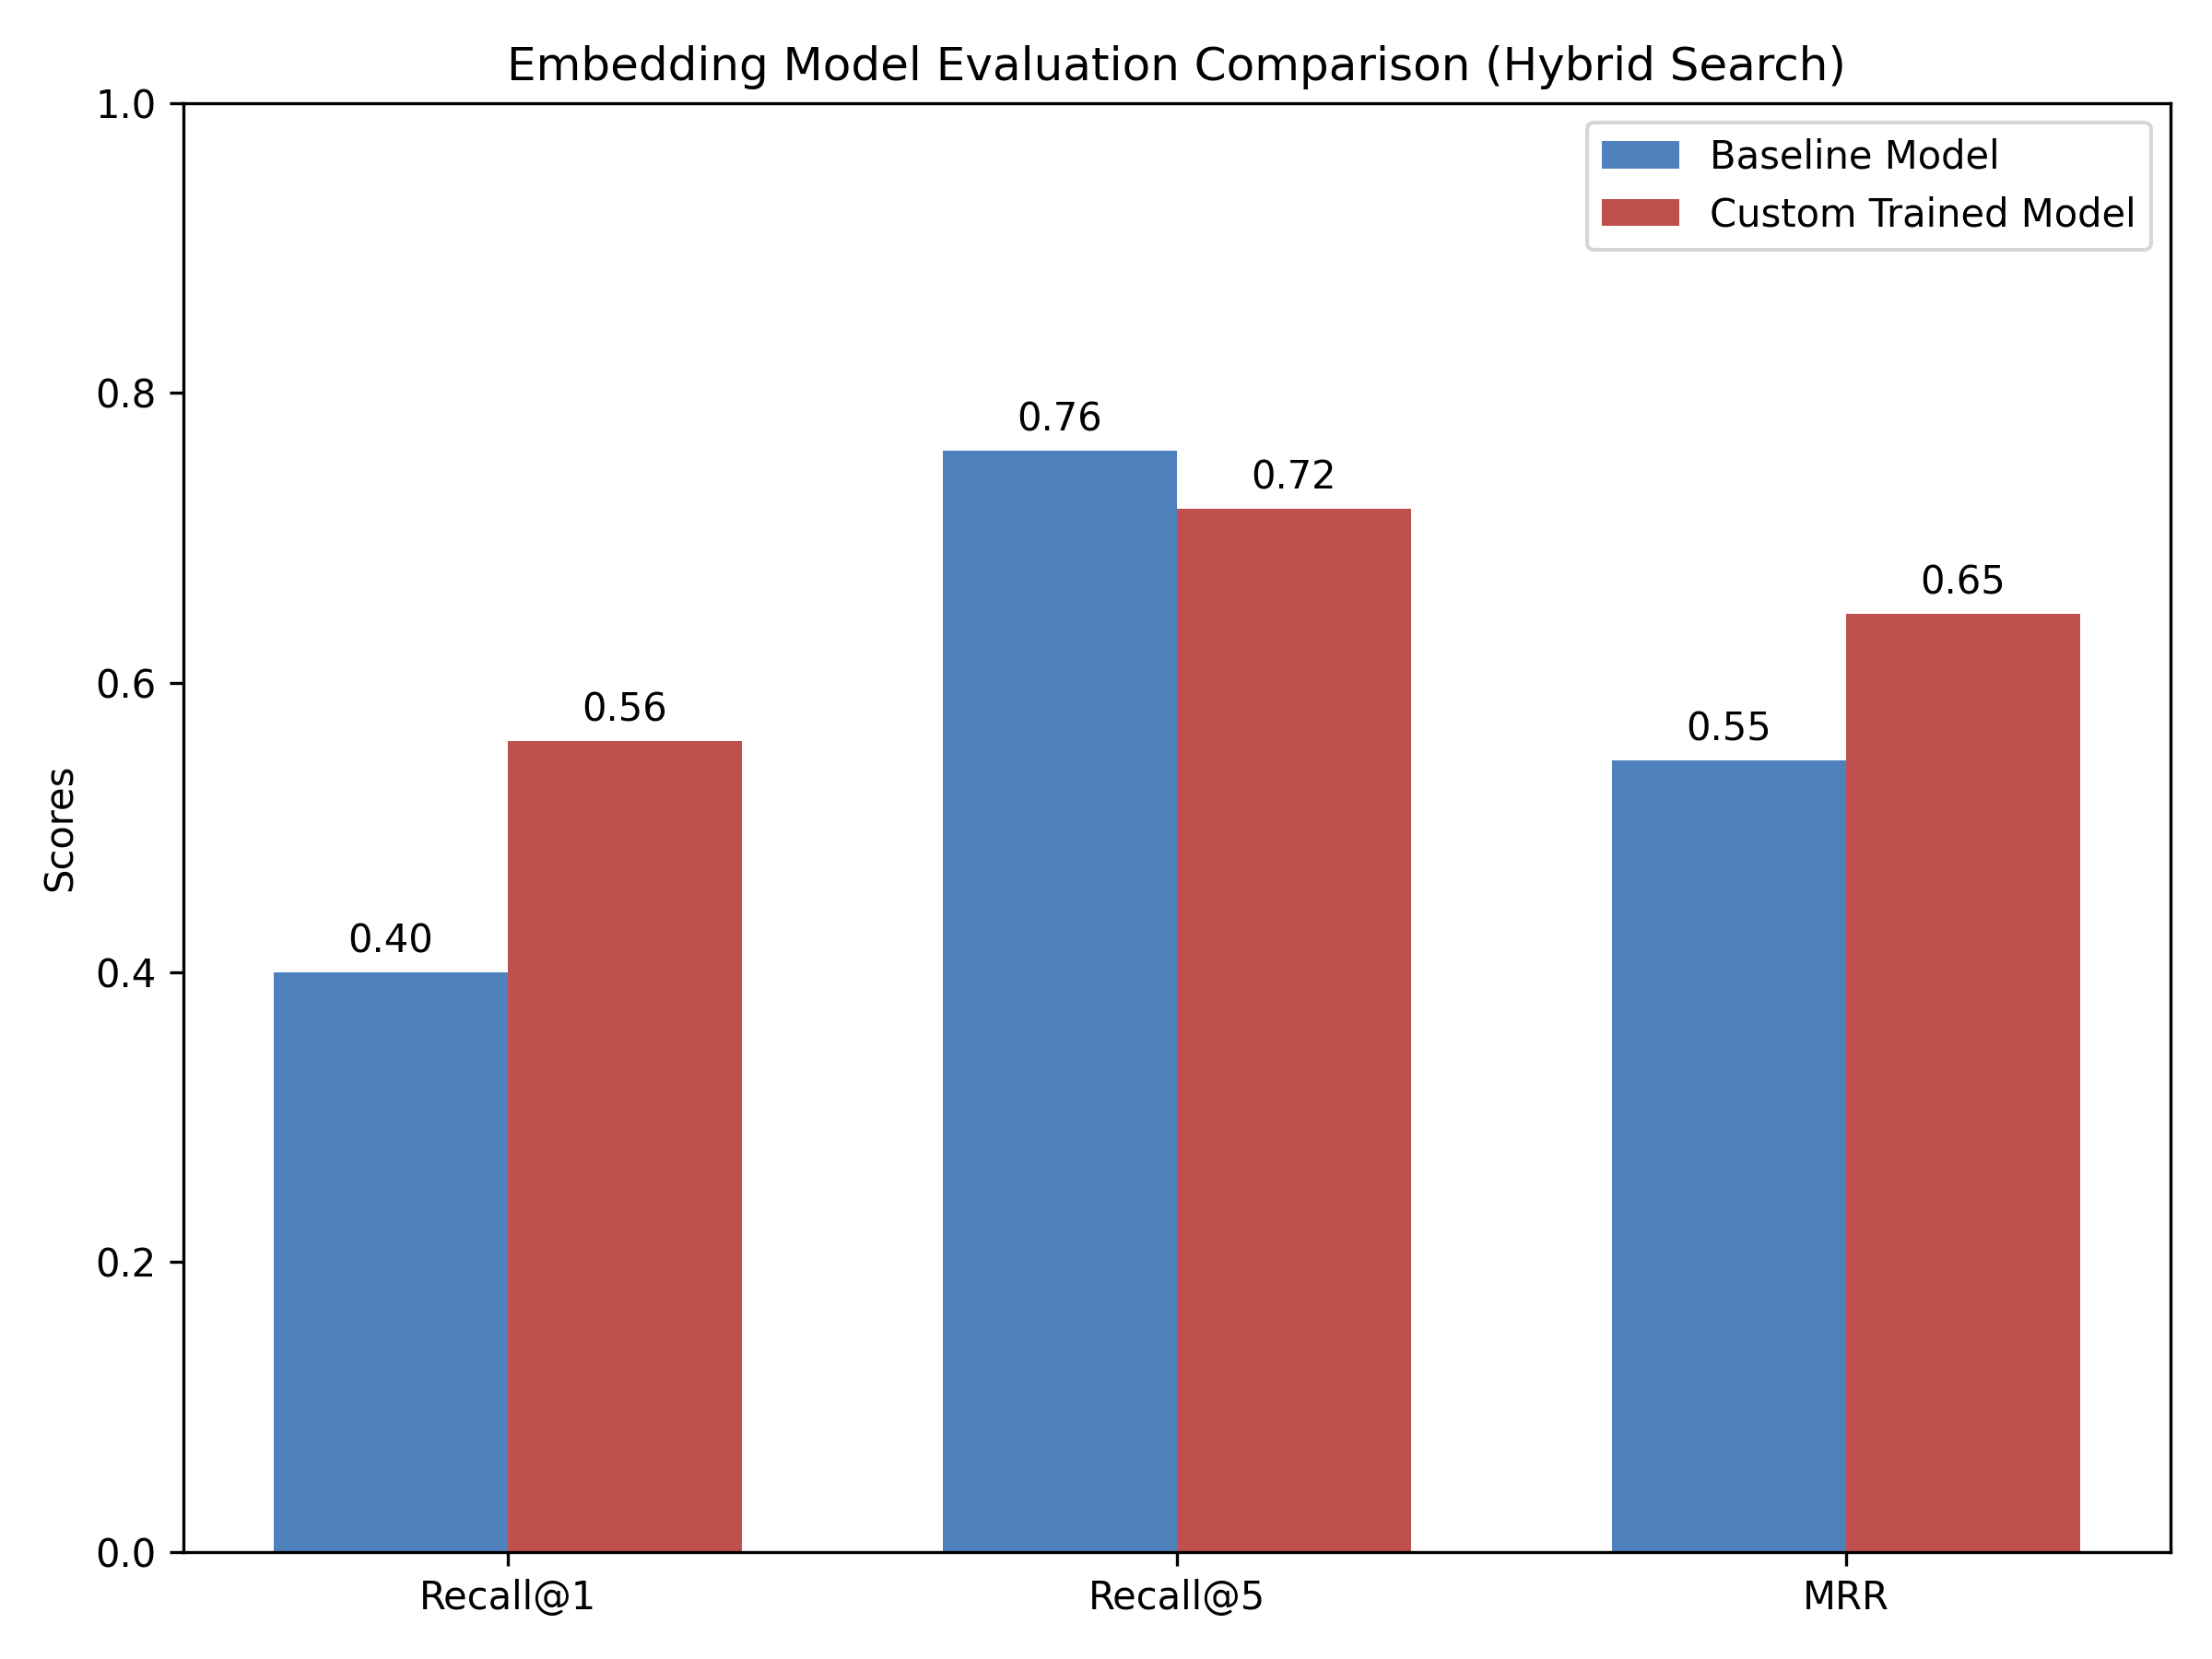

In [9]:
metrics = ['Recall@1', 'Recall@5', 'MRR']
base_scores = [base_r1, base_r5, base_mrr]
custom_scores = [custom_r1, custom_r5, custom_mrr]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, base_scores, width, label='Baseline Model', color='#4f81bd')
rects2 = ax.bar(x + width/2, custom_scores, width, label='Custom Trained Model', color='#c0504d')

ax.set_ylabel('Scores')
ax.set_title('Embedding Model Evaluation Comparison (Hybrid Search)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300)
plt.show()